In [24]:
import math
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
out = "/Volumes/easystore/proton-kaon/images/pk_48x48_log1p.pt"

data = torch.load(out, map_location="cpu")
p = data["p"]
k = data["k"]

<Axes: >

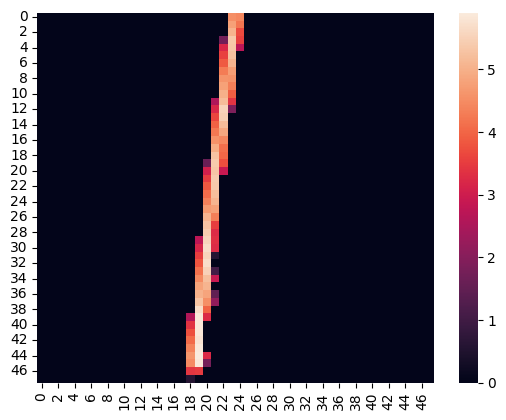

In [26]:
sns.heatmap(p[1099, 0])

<Axes: >

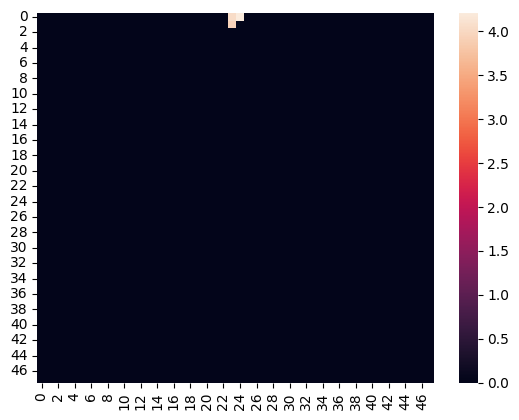

In [27]:
sns.heatmap(k[0, 0])

In [28]:
def n_pixels(image):
    return np.sum(image.numpy() > 0)

protons = [n_pixels(a) for a in p]
kaons = [n_pixels(a) for a in k]

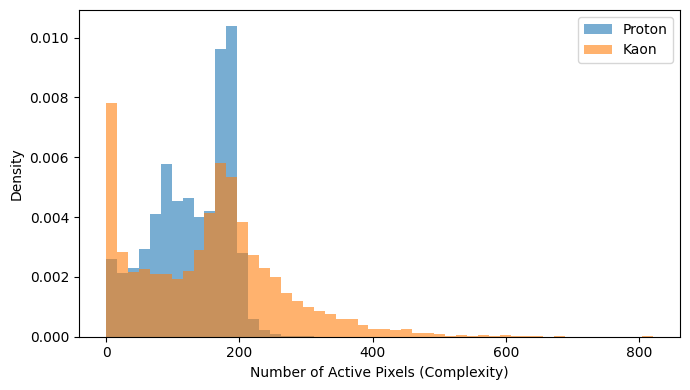

In [29]:
from src.features.plot import hist

combined_min = min(min(protons), min(kaons))
combined_max = max(max(protons), max(kaons))
bin_edges = np.linspace(combined_min, combined_max, 50 + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(protons, bins=bin_edges, alpha=0.6, label='Proton', density=True)
ax.hist(kaons,   bins=bin_edges, alpha=0.6, label='Kaon',   density=True)
ax.set_xlabel('Number of Active Pixels (Complexity)')
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

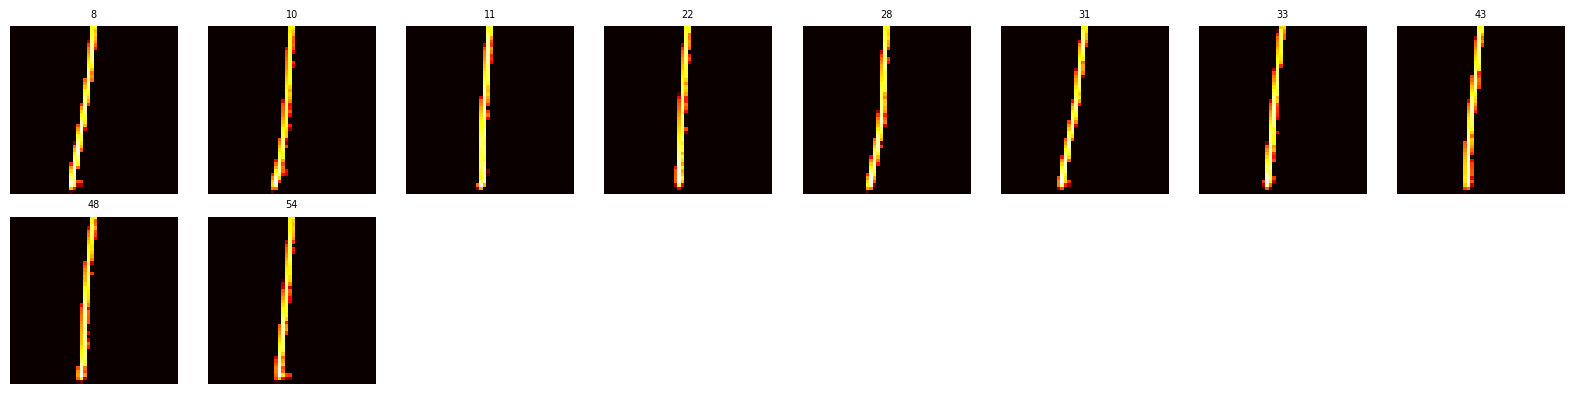

In [ ]:
protons = np.array(protons)  # convert list to array so you can index it
indices = np.where((protons > 180) & (protons < 200))[0][:10]

n = len(indices)
cols = 8
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = p[idx]  # shape (2, H, W)
    axes[i].imshow(img[0].numpy(), cmap='hot')  # channel 0
    axes[i].set_title(idx, fontsize=7)
    axes[i].axis('off')

for ax in axes[n:]:   # hide unused subplots
    ax.axis('off')

plt.tight_layout()
plt.show()

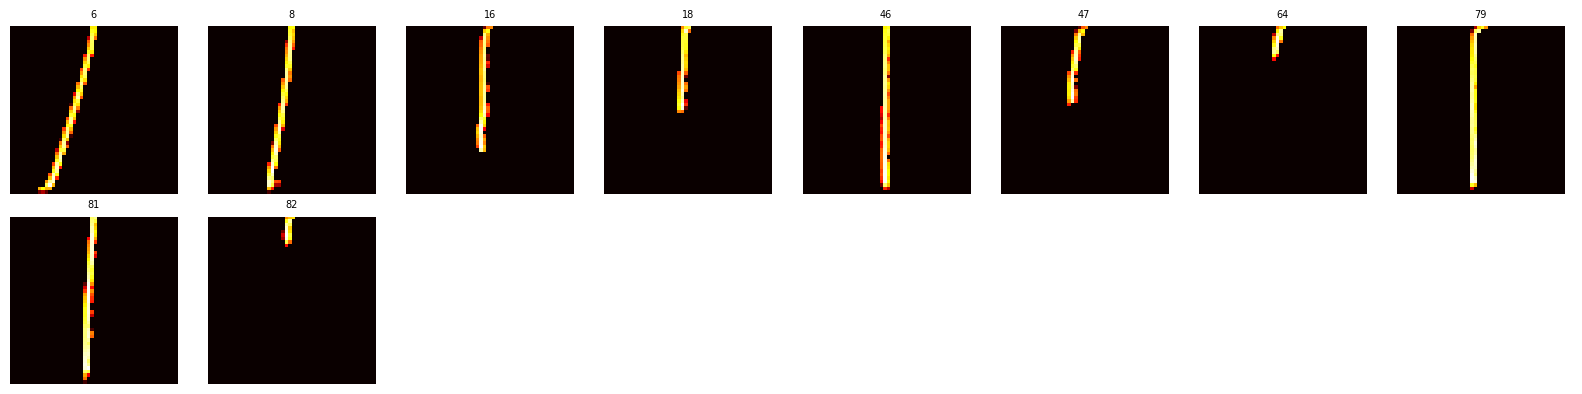

In [31]:
kaons = np.array(kaons)  # convert list to array so you can index it
indices = np.where((kaons > 180) & (kaons < 200))[0][:10]

n = len(indices)
cols = 8
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = p[idx]  # shape (2, H, W)
    axes[i].imshow(img[0].numpy(), cmap='hot')  # channel 0
    axes[i].set_title(idx, fontsize=7)
    axes[i].axis('off')

for ax in axes[n:]:   # hide unused subplots
    ax.axis('off')

plt.tight_layout()
plt.show()